## 1. Problem Statement 

The aim of this project is to use the crime and Disorder Data provided by the City of Calgary's data website to analyze the data and predict the number of crimes that will occur in the future. The data is from 2018 to 2024 and contains the number of crimes that occurred in Calgary for each month. After throughly analyzing the data, i will be building a neural model and optimizing it to predict the number of crimes that will occur in the future.

#### Strategy 
1. Loading the data and understanding the data
2. Data Preprocessing - cleaing the data and preparing it for analysis
3. Exploratory Data Analysis - Analyzing the data to understand the trends and patterns
4. Building a Neural Network Model
5. Optimizing the model
6. Training the model
7. Predicting the number of crimes that will occur in the future

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns

## 2. Data Gathering 

In [2]:
df = pd.read_csv('Community_Crime_Statistics_20240522.csv')
df.head()

,Community,Category,Crime Count,Year,Month
0,01B,Assault (Non-domestic),1,2022,11
1,01B,Break & Enter - Commercial,1,2019,6
2,01B,Break & Enter - Commercial,1,2019,8
3,01B,Break & Enter - Commercial,2,2020,3
4,01B,Break & Enter - Commercial,2,2020,7


## 3. Data Preprocessing 

In [3]:
df.shape

(70661, 5)

In [4]:
df.isnull().sum()

Community      0
Category       0
Crime Count    0
Year           0
Month          0
dtype: int64

In [5]:
df.dtypes

Community      object
Category       object
Crime Count     int64
Year            int64
Month           int64
dtype: object

In [6]:
df.describe()

,Crime Count,Year,Month
count,70661.000000,70661.000000,70661.000000
mean,2.855748,2020.618616,6.369242
std,3.664965,1.825330,3.451445
min,1.000000,2018.000000,1.000000
25%,1.000000,2019.000000,3.000000
50%,2.000000,2021.000000,6.000000
75%,3.000000,2022.000000,9.000000
max,111.000000,2024.000000,12.000000


## 4. Exploratory Data Analysis 

#### Community Distribution 

Text(0, 0.5, '')

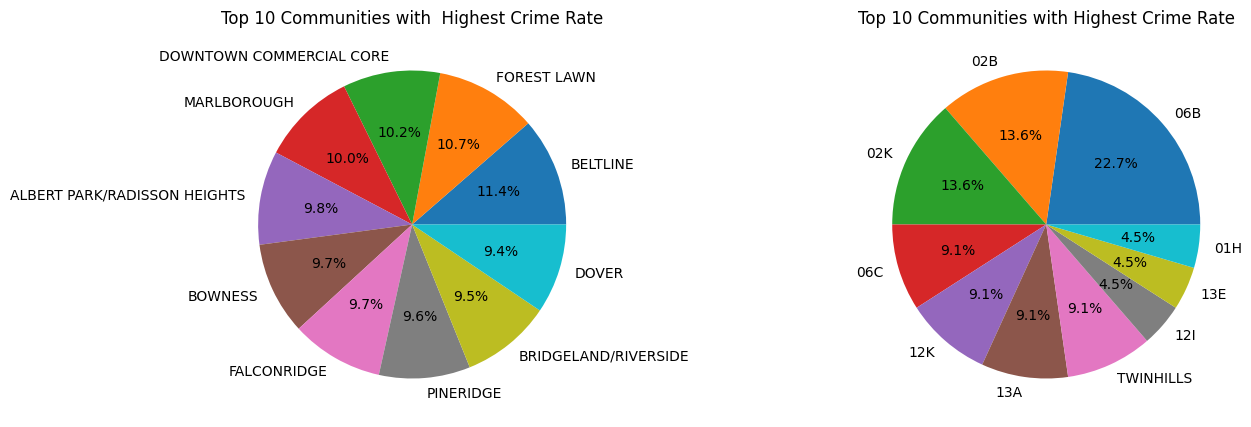

In [7]:
fig, ax = plt.subplots(1,2, figsize = (15,5))

# top 10 Communities with Highest Crime Rate 
df['Community'].value_counts().head(10).plot.pie(autopct = '%1.1f%%',ax = ax[0])
ax[0].set_title('Top 10 Communities with  Highest Crime Rate')
ax[0].set_ylabel('')

# top10 Communities with lowest Crime Rate 
df['Community'].value_counts().tail(10).plot.pie(autopct = '%1.1f%%',ax = ax[1])

ax[1].set_title('Top 10 Communities with Highest Crime Rate')
ax[1].set_ylabel('')

- The first graph tells us 10 communities in calgary is most dengerous 

- The second graph tells us the top 10 safest communities 

#### Crime category distribution 

Text(0, 0.5, '')

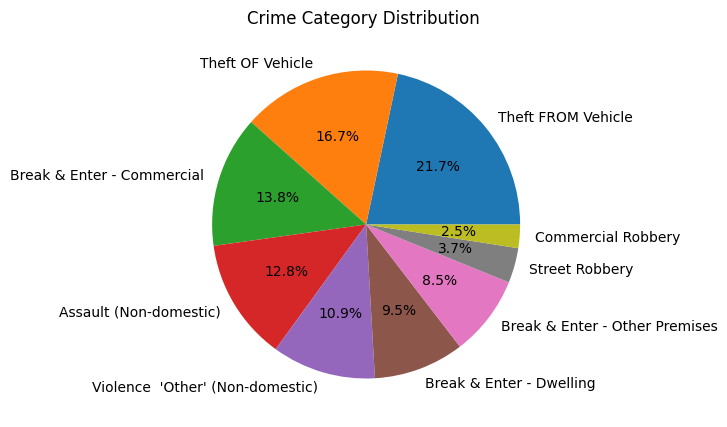

In [8]:
plt.figure(figsize = (5,5))
df['Category'].value_counts().plot.pie(autopct = '%1.1f%%')
plt.title('Crime Category Distribution ')
plt.ylabel('')

This graph shows the distribution of crimes in each category by the number of crimes. The top crime category is Theft from vechicle with 21.1% of the total crimes, followed by theft of Vechicle with 16.7 % and break and enter - Commercial with 13.8%. The least crime category includes commercial or street robbery.

#### Crime Reportings Over the Years `

Text(0.5, 1.0, 'Crime Reportings by Year')

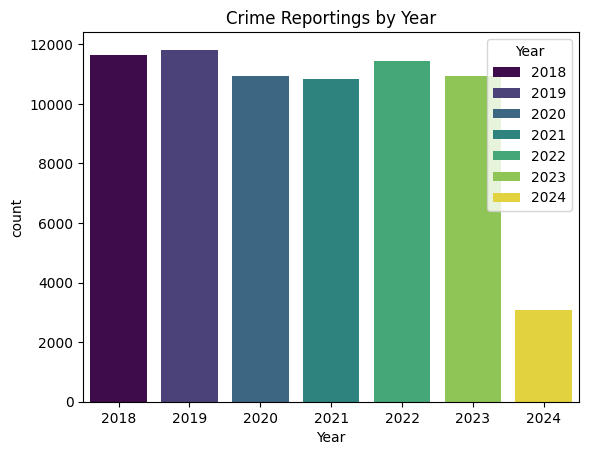

In [9]:
sns.countplot(x = 'Year',data = df, hue = 'Year',palette = 'viridis').set_title('Crime Reportings by Year')

- This bar graph shows the distribution of number of crimes reported in the year.  The year 2019 had the highest reportings of crimes followed by 2022 and 2018. The crime reportings in 2024 are less due to limited data till April 2024

#### Crime Reportings by Month 

Text(0.5, 1.0, 'Crime Reportings by Month')

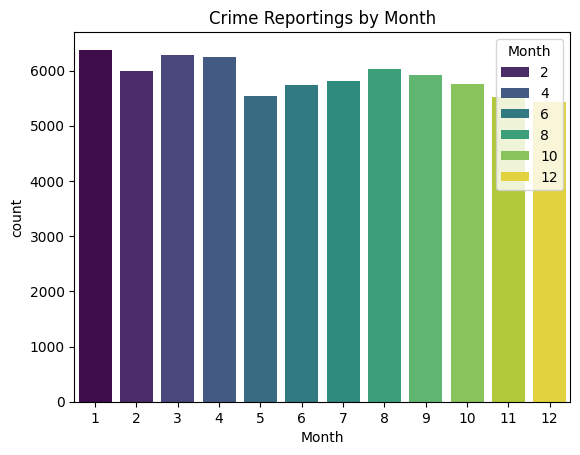

In [10]:
sns.countplot(x = 'Month',data = df, hue = 'Month',palette='viridis').set_title('Crime Reportings by Month')

#### Community and Category Analysis 

Text(0.5, 1.0, 'Top 5 Most safest Community and Crime Category')

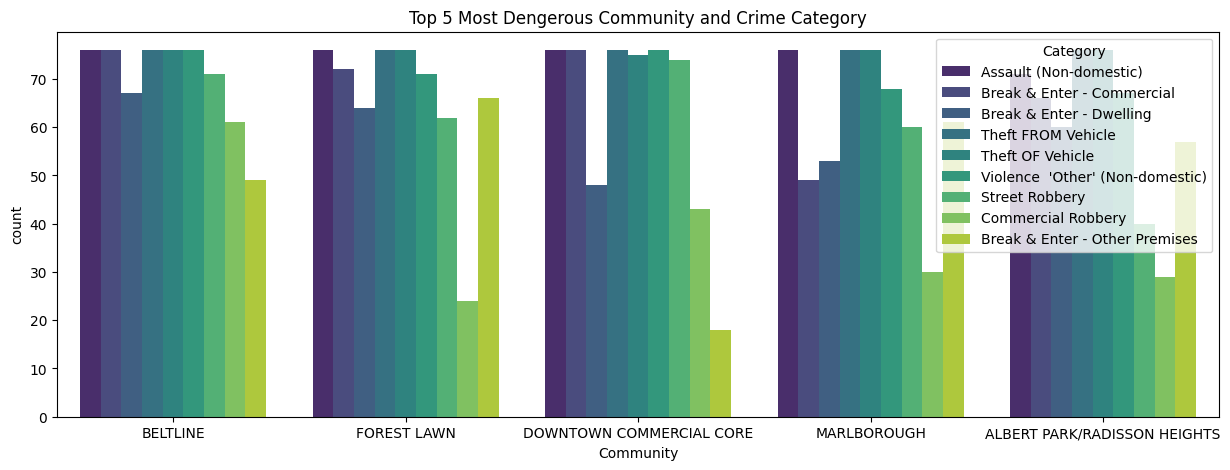

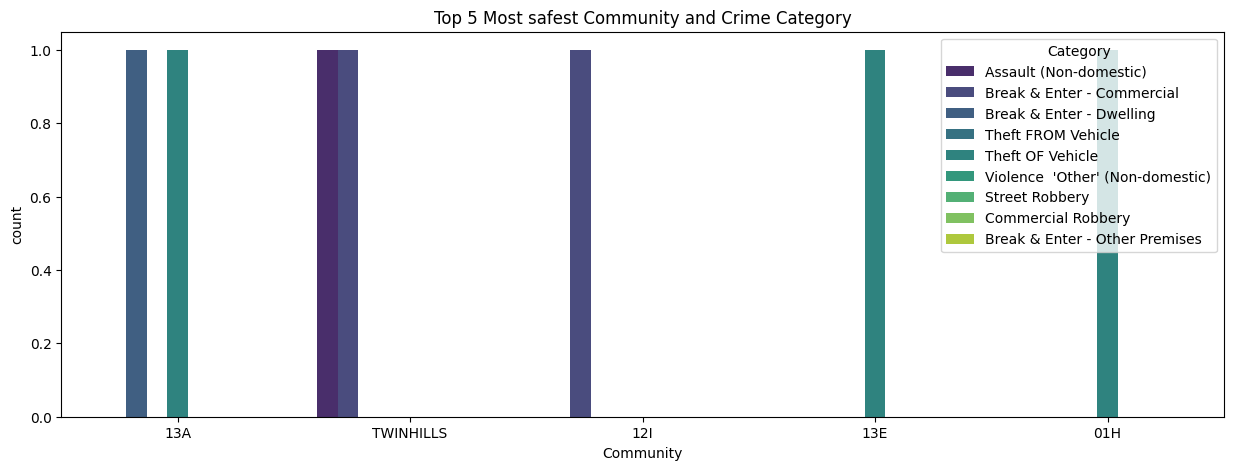

In [11]:
plt.figure(figsize = (15,5))
sns.countplot(x = 'Community',data = df, hue = 'Category',palette = 'viridis',order = df['Community'].value_counts().head(5).index).set_title('Top 5 Most Dengerous Community and Crime Category')
sns.move_legend(plt.gca(),'upper right')
plt.figure(figsize=(15,5))
sns.countplot(x= 'Community',data = df,hue = 'Category',palette = 'viridis',order = df['Community'].value_counts().tail(5).index).set_title('Top 5 Most safest Community and Crime Category')

- These two graps shows the analysis of communities with the crime category. This help us to visualize the patter of crime in each community. We can see that certain categories are more common in certain communities than others. In the top 5 dangerous communities, Forest Lawn has the highest of Break & Enter - Other premises, Malbrough has the lowest Commerical Robbery. These are the few examples of the analysis.

#### Year and Category Analysis 

Text(0.5, 1.0, 'Crime Reportings by year and Crime category')

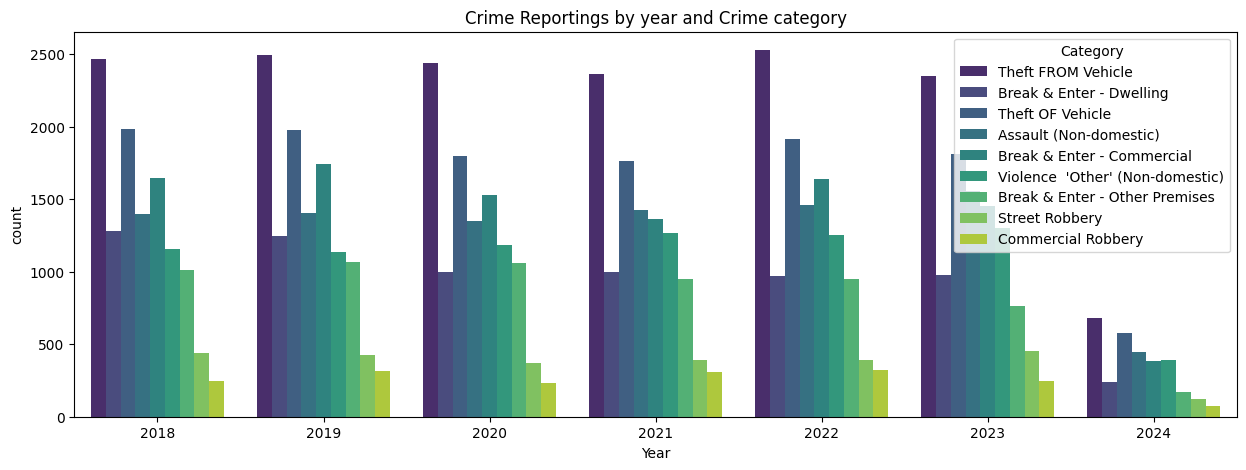

In [12]:
plt.figure(figsize = (15,5))
sns.countplot(x = 'Year',data = df, hue = 'Category',palette = 'viridis').set_title('Crime Reportings by year and Crime category')

#### Month and category Analysis 

Text(0.5, 1.0, 'Crime reportings by Month and Crime Category')

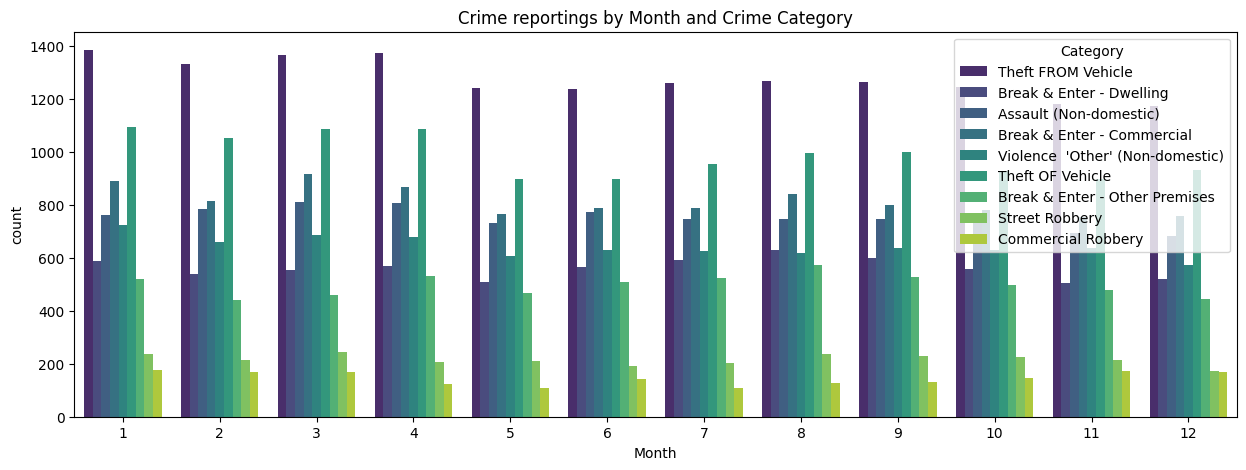

In [13]:
plt.figure(figsize = (15,5))
sns.countplot(x = 'Month',data = df, hue = 'Category',palette = 'viridis').set_title('Crime reportings by Month and Crime Category')

- From the above, graphs, charts, and visualization i have studied the patterns, trends and relationships in the data. This will help me to build a better model for prediction.

## 5. Feature Engineering 

In [14]:
from sklearn.preprocessing import LabelEncoder

In [15]:
le = LabelEncoder()

In [16]:
object_type_cols = df.select_dtypes(include='object').columns

In [17]:
# Label Encoder 
for col in object_type_cols:
    df[col] = le.fit_transform(df[col])

In [18]:
df.head(3)

,Community,Category,Crime Count,Year,Month
0,0,0,1,2022,11
1,0,1,1,2019,6
2,0,1,1,2019,8


In [19]:
def create_sequence(data, seq_length):
    xs = []
    ys = []
    for i in range(len(data) - seq_length):
        x = data.iloc[i:(i + seq_length)].to_numpy()
        y = data.iloc[i + seq_length]['Crime Count']
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

In [23]:
seq_length = 3
x,y = create_sequence(df, seq_length)

## 6. Model Selection 

In [24]:
from sklearn.model_selection import train_test_split

In [25]:
x_train, x_test , y_train, y_test = train_test_split(x,y, test_size=0.3, random_state=42)

In [27]:
x_val, x_test, y_val, y_test = train_test_split(x_test, y_test,test_size=0.5,random_state= 42)

#### Building and Training the LSTM model 

In [34]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam 

In [32]:
pip install tensorflow

   ---------------------------------------- 0.0/332.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/332.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/332.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/332.0 MB 668.8 kB/s eta 0:08:16
   ---------------------------------------- 0.5/332.0 MB 668.8 kB/s eta 0:08:16
   ---------------------------------------- 0.8/332.0 MB 774.5 kB/s eta 0:07:08
   ---------------------------------------- 0.8/332.0 MB 774.5 kB/s eta 0:07:08
   ---------------------------------------- 1.0/332.0 MB 687.7 kB/s eta 0:08:02
   ---------------------------------------- 1.3/332.0 MB 775.3 kB/s eta 0:07:07
   ---------------------------------------- 1.6/332.0 MB 805.9 kB/s eta 0:06:51
   ---------------------------------------- 1.8/332.0 MB 889.6 kB/s eta 0:06:12
   ---------------------------------------- 1.8/332.0 MB 889.6 kB/s eta 0:06:12
   ---------------------------------------- 1.8/332.0 MB 889.6 kB/s

In [33]:
# !pip install tensorflow

- RELU - The Rectified Linear Unit (ReLU) is the default, non-linear activation function for most modern deep learning models, particularly CNNs and deep neural networks. Defined as \(f(x)=\max (0,x)\), it outputs the input directly if positive, and zero otherwise. 

In [36]:
model = Sequential()
model.add(LSTM(50,activation = 'relu',input_shape = (seq_length, x_train.shape[2])))
model.add(Dropout(0.2))
model.add(Dense(1))

C:\Users\khedk\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [37]:
# Compile the model 
optimizer = Adam(learning_rate= 0.001)
model.compile(optimizer=optimizer,loss='mse')

In [38]:
#train the model 
history = model.fit(x_train,y_train,epochs=100,validation_data=(x_val,y_val),batch_size=16)

Epoch 1/100
3092/3092 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 537.6094 - val_loss: 11.7225
Epoch 2/100
3092/3092 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 11.6434 - val_loss: 7.3392
Epoch 3/100
3092/3092 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 6.6943 - val_loss: 7.2567
Epoch 4/100
3092/3092 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 6.5171 - val_loss: 4.7613
Epoch 5/100
3092/3092 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 6.1900 - val_loss: 5.1006
Epoch 6/100
3092/3092 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 6.1727 - val_loss: 5.0667
Epoch 7/100
3092/3092 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - loss: 6.0393 - val_loss: 7.6485
Epoch 8/100
3092/3092 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - loss: 6.0187 - val_loss: 4.9905
Epoch 9/100
3092/3092 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 6.1184 - val_loss: 5.2320
Epoch 10/100
3092/3092 ━━━━━━━━━━━━━━━━━━━━ 38s 6ms/step - loss: 5.9745 - val_loss: 5.1463
Epoch 11/100
3092/3092 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - loss: 5.8844 - val_loss: 5.0616
Epoch 12/

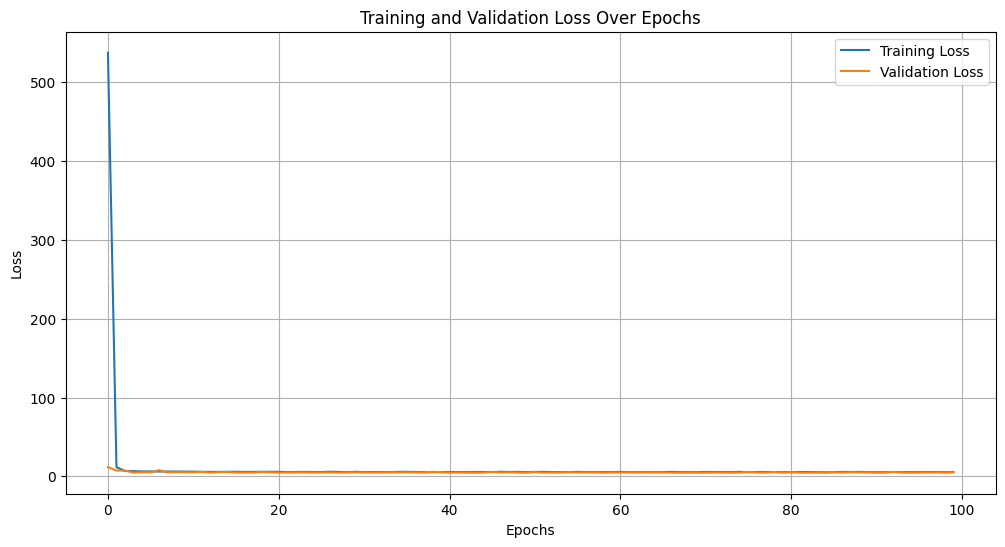

In [40]:
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [42]:
# Evaluate the model
test_loss = model.evaluate(x_test, y_test)
print(f'Test Loss: {test_loss}')

# Predictions
y_pred = model.predict(x_test)


print(f'Predictions: {y_pred.flatten()}')
print(f'True Values: {y_test.flatten()}')


332/332 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.0351
Test Loss: 5.035118103027344
332/332 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Predictions: [3.3477051 1.6798291 1.9203831 ... 3.5326133 1.3599262 2.6755471]
True Values: [2 1 1 ... 1 2 2]


## 7. Model Evaluation 

#### Actual vs Predicted Values 

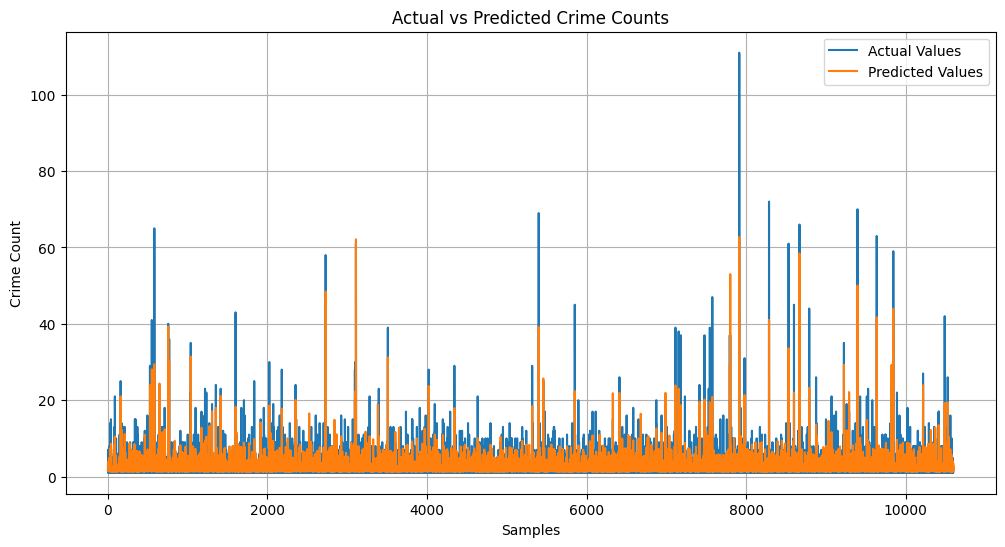

In [43]:
# Plotting Actual vs Predicted Values
plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Actual Values')
plt.plot(y_pred, label='Predicted Values')
plt.title('Actual vs Predicted Crime Counts')
plt.xlabel('Samples')
plt.ylabel('Crime Count')
plt.legend()
plt.grid(True)
plt.show()


#### Residual Plot 

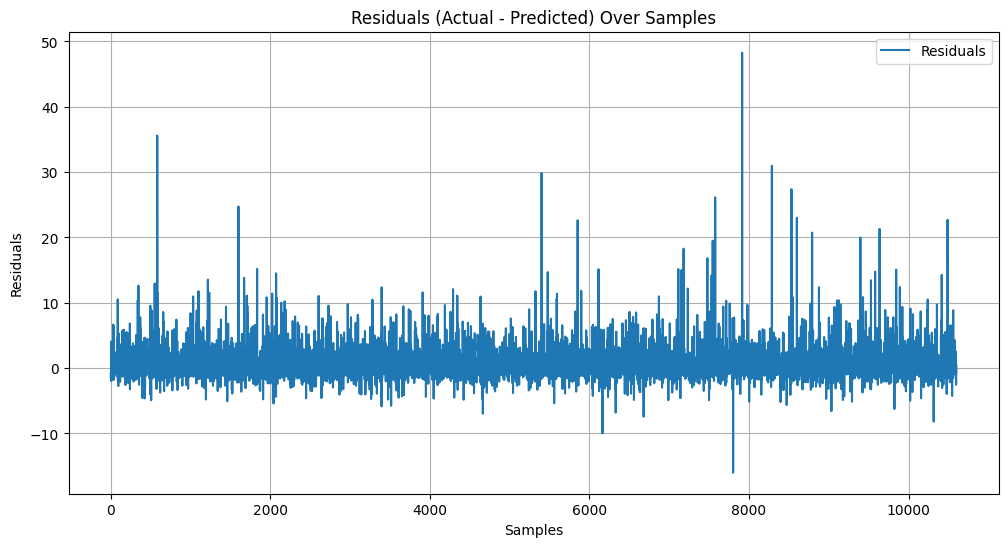

In [45]:
# Calculating residuals
residuals = y_test.flatten() - y_pred.flatten()

# Plotting residuals
plt.figure(figsize=(12, 6))
plt.plot(residuals, label='Residuals')
plt.title('Residuals (Actual - Predicted) Over Samples')
plt.xlabel('Samples')
plt.ylabel('Residuals')
plt.legend()
plt.grid(True)
plt.show()